In [46]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import seaborn as sns
from matplotlib import pyplot as plt

# Joining datasets on `patient_id`

In [47]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
complaints_df = pd.read_csv("dataset/chief_complaints.csv")
histsory_df = pd.read_csv("dataset/patient_history.csv")
patient_info_df = complaints_df.merge(
    histsory_df,
    on="patient_id",
    how="outer"
)

train_df.drop(columns=["chief_complaint_system"], inplace=True)
test_df.drop(columns=["chief_complaint_system"], inplace=True)

train_full_df = train_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

test_full_df = test_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

train_full_df.to_csv("dataset/train_dataset.csv", index=False)
test_full_df.to_csv("dataset/test_dataset.csv", index=False)

train_df = train_full_df
test_df = test_full_df

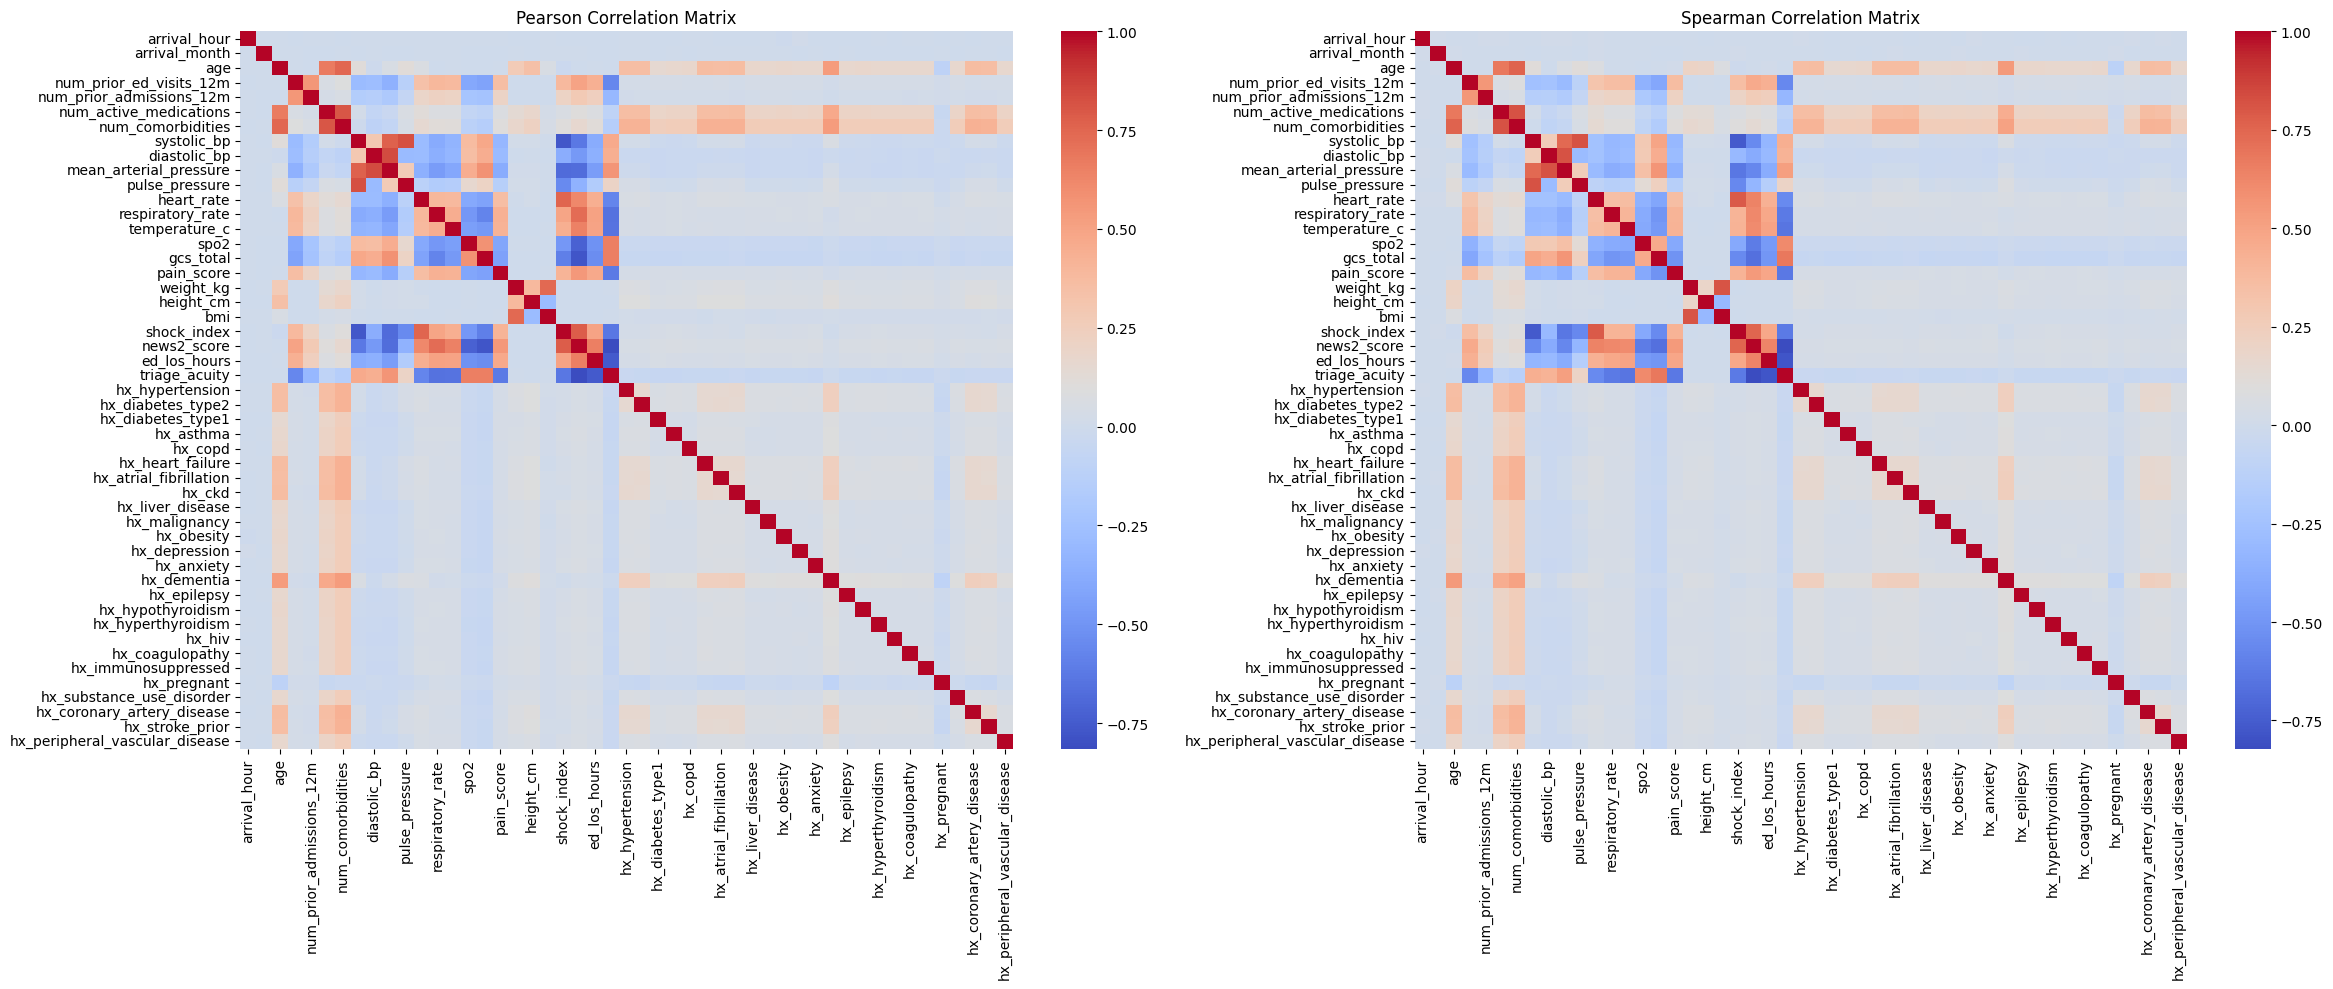

In [48]:
fig, ax = plt.subplots(1,2, figsize=(24, 10))

pearson_corr_matrix = train_df.corr(numeric_only=True, method='pearson')
spearman_corr_matrix = train_df.corr(numeric_only=True, method='spearman')

sns.heatmap(pearson_corr_matrix, cmap="coolwarm", ax=ax[0])
sns.heatmap(spearman_corr_matrix, cmap="coolwarm", ax=ax[1])

ax[0].set_title("Pearson Correlation Matrix")
ax[1].set_title("Spearman Correlation Matrix")

plt.tight_layout()
plt.show()

In [49]:
print("Sorted correlation values with triage_acuity by absolute value")
print("Pearson Correlation:")
print(abs(pearson_corr_matrix["triage_acuity"]).sort_values(ascending=False))
print("Spearman Correlation:")
print(abs(spearman_corr_matrix["triage_acuity"]).sort_values(ascending=False))

Sorted correlation values with triage_acuity by absolute value
Pearson Correlation:
triage_acuity                     1.000000
news2_score                       0.814804
ed_los_hours                      0.756714
gcs_total                         0.656620
spo2                              0.654399
respiratory_rate                  0.652945
temperature_c                     0.649193
shock_index                       0.631830
pain_score                        0.618834
heart_rate                        0.567962
num_prior_ed_visits_12m           0.564138
mean_arterial_pressure            0.561726
systolic_bp                       0.462352
diastolic_bp                      0.444031
num_prior_admissions_12m          0.311197
pulse_pressure                    0.200209
num_comorbidities                 0.142150
num_active_medications            0.094220
hx_hyperthyroidism                0.053749
hx_liver_disease                  0.052915
hx_coagulopathy                   0.051430
hx_anxiety   

In [54]:
train_df['disposition'].unique()

array(['discharged', 'transferred', 'observation', 'admitted', 'deceased',
       'lwbs', 'lama'], dtype=object)

## NOTE
An important consideration should be done about the fact that we only have `acuity_level`, `disposition` and `ed_los_hours` in the `train.csv` dataset, and not in the `test.csv` dataset. 

The abbreviation `ED` stands for `Emergency Department`, and `LOS` stands for `Length of Stay`. So, `ed_los_hours` is the length of stay in the emergency department, measured in hours.
## Disposition
Also, `disposition` refers to the outcome of the patient's visit to the emergency department, such as whether they were admitted to the hospital, discharged, transferred to another facility, etc.
### Patient Dispositions in the ED

- **discharged**  
  The patient was **released** from the emergency department and can go home.

- **transferred**  
  The patient was **transferred** to another hospital or facility for further care.

- **observation**  
  The patient was placed under **observation**, usually in a dedicated area or ward, to monitor symptoms before making a final decision.

- **admitted**  
  The patient was **admitted** to the hospital for more intensive care.

- **deceased**  
  The patient **passed away** while in the emergency department.

- **lwbs** (Left Without Being Seen)  
  The patient **left the ED before being seen** by a doctor.

- **lama** (Leave Against Medical Advice)  
  The patient **left the ED against medical advice**.

## Acuity Level
`Acuity level` is a measure of the severity of the patient's condition, which can help healthcare providers prioritize care and allocate resources effectively.

Ofc those are not present in the `test.csv` dataset, but they are present in the `train.csv` dataset.

## Considerations
WE CANNOT USE `acuity_level`, `disposition` and `ed_los_hours` in the training phase, because they are not present in the test set. However, since the task is to both predict `triage_acuity`, both present something innovative medically speaking, we can validate our model by looking at our predictions during the training phase and seeing how they correlate with `acuity_level`, `disposition` and `ed_los_hours`.

## ESI and triage acuity
triage acuity is a measure of the severity of a patient's condition, which can help healthcare providers prioritize care and allocate resources effectively. The Emergency Severity Index (ESI) is a commonly used triage system that categorizes patients into **five levels** based on the severity of their condition and the resources they are likely to require. The ESI levels are as follows:
- ESI Level 1: Patients with life-threatening conditions that require **immediate intervention**.
- ESI Level 2: Patients with high-risk conditions that require **urgent care**.
- ESI Level 3: Patients with **stable conditions** that require **multiple resources**.
- ESI Level 4: Patients with stable conditions that require **one resource**.
- ESI Level 5: Patients with stable conditions that require **no resources**.


# Train & Test datasets overview

In [50]:
print(f"train_df shape:\n{train_df.shape}\n")
print(f"test_df shape:\n{test_df.shape}\n")


# print(f"train_df dtypes:\n{train_df.dtypes.to_string()}")
# print(f"test_df dtypes:\n{test_df.dtypes.to_string()}")

train_fields = train_df.columns
test_fields = test_df.columns

missing_fields = [field for field in train_fields if field not in test_fields]
print(f"test_df is missing {missing_fields} attributes")

print(f"{train_df.loc[0].to_string()}")

train_df shape:
(80000, 66)

test_df shape:
(20000, 63)

test_df is missing ['disposition', 'ed_los_hours', 'triage_acuity'] attributes
patient_id                                                         TG-UXRGA9UCO
site_id                                                             SITE-TMP-01
triage_nurse_id                                                      NURSE-0033
arrival_mode                                                            walk-in
arrival_hour                                                                  6
arrival_day                                                              Monday
arrival_month                                                                 5
arrival_season                                                           spring
shift                                                                   morning
age                                                                          43
age_group                                                       

# DBG files containing attributes informations

In [51]:
of = open("DBG/categorical_describe.txt", "w")
of.write(train_df.describe(include=[object]).to_string())
of.close()

of = open("DBG/numerical_describe.txt", "w")
of.write(train_df.describe(exclude=[object]).to_string())
of.close()

of = open("DBG/nans_per_col.txt", "w")
of.write(train_df.isna().sum(axis=0).to_string())
of.close()

nans_per_row = train_df.isna().sum(axis=1)
mean = nans_per_row.mean()
std = nans_per_row.std()

print(f"the average number of missing values per row is: {mean}, with a standard deviation of {std}")

the average number of missing values per row is: 0.3046375, with a standard deviation of 1.1407233491148239


The columns containing the highest number of missing values are:
- systolic_bp
- diastolic_bp
- mean_arterial_pressure
- pulse_pressure
- shock_index

all of which have 4146 nans (~ 5% of all samples)

---

Some discussion can be done on categorical features, as some of them have few unique values (even though many are justified, like `sex` and `season`) and others have many unique values but one of these represents half of the samples (like `insurance_type` which is equal to `public` in ~60% of the population)

---

As for numerical attributes, some have very low variance (< 1), but that could depend on the unit of measure and the intrinsic meaning of the attribute, thus further discussion must be performed.

# Mock pipeline

In [52]:
y_train = train_df['triage_acuity']
train_df_clean = train_df.drop(columns=['patient_id','disposition', 'ed_los_hours', 'triage_acuity', 'chief_complaint_raw'])


categoricals = [field for field in train_df_clean.columns if train_df_clean.dtypes[field] == object]
numericals = [field for field in train_df_clean.columns if train_df_clean.dtypes[field] != object]

preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy='most_frequent')),
                    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
                ]
            ),
            categoricals
        ),
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer()),
                    ("scal", StandardScaler())
                ]
            ),
            numericals
        )
    ],
    remainder = "drop"
)

X_train, X_val, y_train_split, y_val = train_test_split(train_df_clean, y_train, train_size=0.6, random_state=42, stratify=y_train)

print(f"starting preprocessing...")

X_train_pp = preprocessor.fit_transform(X_train)
X_val_pp = preprocessor.transform(X_val)

print(f"final dimensionality: {X_train_pp.shape}")

clf = RandomForestClassifier(
    n_estimators = 100,
    criterion = 'log_loss',
    max_depth = 25,
    min_samples_split = 10,
    min_samples_leaf = 2,
    max_features = 'sqrt',
    n_jobs = -1,
    random_state = 42
)

print(f"starting fitting...")
clf.fit(X_train_pp, y_train_split)

print(f"fitting done, starting predicting...")
y_pred = clf.predict(X_val_pp)

acc = accuracy_score(y_val, y_pred)
print(f"predicting done, overall accuracy: {acc}")

starting preprocessing...
final dimensionality: (48000, 178)
starting fitting...
fitting done, starting predicting...
predicting done, overall accuracy: 0.8255
